<a href="https://colab.research.google.com/github/chiamakachijioke/urban-mobility-optimisation/blob/main/notebooks/03_Dijkstra_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dijkstra's Shortest Path Algorithm**

This notebook implements Dijkstra's algorithm from scratch.

The algorithm will find the shortest path between a starting node and a destination node in a weighted transport graph.

The graph contains only non-negative edge weights, so Dijkstra's algorithm is suitable.

# Import the librries


In [ ]:
# Import the librries

import math
import heapq

import matplotlib.pyplot as plt
import networkx as nx

The new library here is:

***heapq***

It helps us efficiently select the node with the smallest known distance.

This is called a priority queue.

# Recreate same data as others

In [ ]:
# Recreate the location data

locations = {
    0: {"name": "Depot", "x": 50, "y": 50, "demand": 0},
    1: {"name": "Customer 1", "x": 20, "y": 30, "demand": 4},
    2: {"name": "Customer 2", "x": 80, "y": 25, "demand": 6},
    3: {"name": "Customer 3", "x": 15, "y": 75, "demand": 3},
    4: {"name": "Customer 4", "x": 65, "y": 80, "demand": 7},
    5: {"name": "Customer 5", "x": 40, "y": 20, "demand": 5},
    6: {"name": "Customer 6", "x": 90, "y": 60, "demand": 4},
    7: {"name": "Customer 7", "x": 30, "y": 90, "demand": 6},
    8: {"name": "Customer 8", "x": 70, "y": 45, "demand": 2},
    9: {"name": "Customer 9", "x": 45, "y": 70, "demand": 5},
}

In [ ]:
# Recreate the distance function
# This is the straight-line distance between two locations.

def euclidean_distance(node_a, node_b, location_data):
    x1 = location_data[node_a]["x"]
    y1 = location_data[node_a]["y"]

    x2 = location_data[node_b]["x"]
    y2 = location_data[node_b]["y"]

    distance = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    return round(distance, 2)

In [ ]:
# Recreate the road connections
# Each tuple represents one direct road.

connections = [
    (0, 1),
    (0, 8),
    (0, 9),

    (1, 3),
    (1, 5),

    (2, 5),
    (2, 6),
    (2, 8),

    (3, 7),
    (3, 9),

    (4, 6),
    (4, 7),
    (4, 8),
    (4, 9),

    (6, 8),

    (7, 9),

    (8, 9),
]

In [ ]:
# Recreate an adjacency list
# An adjacency list stores the neighbours of every node.

graph = {
    node: {}
    for node in locations
}

# Every node exists, but no neighbours have been added yet.
# Now to add the roads:

for node_a, node_b in connections:
    road_distance = euclidean_distance(
        node_a,
        node_b,
        locations
    )

    graph[node_a][node_b] = road_distance
    graph[node_b][node_a] = road_distance

# Check it
graph

{0: {1: 36.06, 8: 20.62, 9: 20.62},
 1: {0: 36.06, 3: 45.28, 5: 22.36},
 2: {5: 40.31, 6: 36.4, 8: 22.36},
 3: {1: 45.28, 7: 21.21, 9: 30.41},
 4: {6: 32.02, 7: 36.4, 8: 35.36, 9: 22.36},
 5: {1: 22.36, 2: 40.31},
 6: {2: 36.4, 4: 32.02, 8: 25.0},
 7: {3: 21.21, 4: 36.4, 9: 25.0},
 8: {0: 20.62, 2: 22.36, 4: 35.36, 6: 25.0, 9: 35.36},
 9: {0: 20.62, 3: 30.41, 4: 22.36, 7: 25.0, 8: 35.36}}

# **Understanding the idea behind Dijkstra**


## How Dijkstra's algorithm works

Dijkstra's algorithm begins at the starting node.

It gives the starting node a distance of 0 and gives every other node an initial distance of infinity.

It repeatedly selects the unvisited node with the smallest known distance.

It then checks whether travelling through that node gives a shorter route to any of its neighbours.

If a shorter route is found, the neighbour's distance and predecessor are updated.

The process continues until the destination is reached or all reachable nodes have been processed.

# Create the Dijkstra function


In [ ]:
# Create the Dijkstra function
# Step1: Make sure the start and destination nodes exist

def dijkstra(graph_data, start_node, destination_node):
    if start_node not in graph_data:
        raise ValueError(
            f"Start node {start_node} does not exist."
        )

    if destination_node not in graph_data:
        raise ValueError(
            f"Destination node {destination_node} does not exist."
        )

    # Step 2: Create a variable "distances" that stores the best known shortest; every node is assumed to be infinitely far away.
    distances = {
        node: math.inf
        for node in graph_data
    }

    # Step 3: Another variable, "predecessors", that stores the previous node used to reach each node through the best known path.
    predecessors = {
        node: None
        for node in graph_data
    }

    # Set the distance from the starting node to itself to zero.
    distances[start_node] = 0

    # Create another variable that stores nodes waiting to be explored, ordered by their known distance
    # It will be in this form: (distance, node)
    unvisited_queue = [
        (0, start_node)
    ]

    # Create an empty set that stores nodes whose shortest distance has already been confirmed.
    visited_nodes = set()

    # Keep running the algorithm while the queue is not empty. As long as there are still nodes waiting to be explored
    # heapq.heappop() removes the item with the smallest distance from the queue.
    while unvisited_queue:
        current_distance, current_node = heapq.heappop(
            unvisited_queue
        )

        if current_node in visited_nodes:
            continue

        visited_nodes.add(current_node)

        if current_node == destination_node:
            break

        # Examine all neighbours
        # This goes through every node directly connected to the current node
        for neighbour, edge_weight in graph_data[
            current_node
        ].items():

            new_distance = (
                current_distance
                + edge_weight
            )                                     # RELAXATION: Calculates the cost of reaching that neighbour through the current node.

            # check whether the new route is better than the route already stored
            if new_distance < distances[neighbour]:
                distances[neighbour] = new_distance       # If better, update the distance
                predecessors[neighbour] = current_node     # This records the previous node in the best path

                heapq.heappush(
                    unvisited_queue,
                    (
                        new_distance,
                        neighbour
                    )
                )

    return (
        distances,
        predecessors,
        visited_nodes
    )

# **Understand the important variables**


## Important variables

- `distances` stores the best known distance from the starting node to every node.
- `predecessors` stores the previous node used to reach each node through the best known path.
- `unvisited_queue` stores nodes waiting to be explored, ordered by their known distance.
- `visited_nodes` stores nodes whose shortest distance has already been confirmed.

ALSO, on each loop:

    neighbour is the connected node, while:*italicized text*
    edge_weight is the cost of travelling directly to it.

## **The while loop**

to remove the closest waiting node
```
current_distance, current_node = heapq.heappop(
    unvisited_queue
)
```

This removes the item with the smallest distance from the queue.

Suppose the queue contains:
```
[
    (36.06, 0),
    (22.36, 5),
    (45.28, 3)
]
```
```heapq.heappop()``` removes:

```(22.36, 5)```

because ```22.36``` is the smallest distance.

Python assigns:
```
current_distance = 22.36
current_node = 5
```
So the algorithm now says:

Node 5 is currently the nearest unprocessed node, so I will examine it next.

## Examine all neighbours
```
for neighbour, edge_weight in graph_data[
    current_node
].items():
```
This goes through every node directly connected to the current node.

Suppose:
```
current_node = 0
```
and:
```
graph_data[0] = {
    1: 36.06,
    8: 20.62,
    9: 20.62
}
```
The loop examines:
```
Neighbour 1, edge weight 36.06
Neighbour 8, edge weight 20.62
Neighbour 9, edge weight 20.62
```
So on each loop:
```
neighbour is the connected node, while:
```
```
edge_weight is the cost of travelling directly to it.
```
Calculate the new possible distance
```
new_distance = (
    current_distance
    + edge_weight
)
```
This asks:

How much would it cost to reach this neighbour through the current node?

For example:
```
current_distance = 36.06
edge_weight = 20.62
```
Then:
```
new_distance = 56.68
```
That means:

The start node can reach this neighbour through the current node at a total cost of 56.68.

It is not only using the edge itself. It adds:
```
Distance from the start to the current node
+
Distance from the current node to the neighbour
```
Compare it with the best known distance
```
if new_distance < distances[neighbour]:
```
This checks whether the new route is better than the route already stored.

Suppose:
```
distances[8] = 90
new_distance = 56.68
```
Since:
```
56.68 < 90
```
the new route is better.

But when:
```
distances[8] = 50
new_distance = 56.68
```
the new route is worse, so nothing changes.

This comparison is called relaxation.

## Update the distance
```
distances[neighbour] = new_distance
```
When the new route is better, the algorithm replaces the old distance.

For example:
```
distances[8] = 90
```
becomes:
```
distances[8] = 56.68
```
This now becomes the best known distance to node 8.

## Store how the neighbour was reached
predecessors[neighbour] = current_node

This records the previous node in the best path.

For example:
```
predecessors[8] = 0
```
means:
```
The best currently known route to node 8 reaches it through node 0.
```
This information is later used to reconstruct the actual path.

For example, these predecessor values:
```
predecessors[6] = 8
predecessors[8] = 0
predecessors[0] = 1
```
allow us to trace backwards:
```
6 ← 8 ← 0 ← 1
```
Then reverse it:
```
1 → 0 → 8 → 6
```

## Relaxation

Relaxation means checking whether a newly discovered route to a node is shorter than the best route already known.

If the new distance is smaller, the stored distance and predecessor are updated.

# Run Dijkstra

In [ ]:
# Run Dijkstra
# I'd use node 1 as the start and node 6 as the destination

start_node = 1
destination_node = 6

distances, predecessors, visited_nodes = dijkstra(
    graph,
    start_node,
    destination_node
)

In [ ]:
# print the shortest distance

print(
    "Shortest distance from",
    start_node,
    "to",
    destination_node,
    ":",
    round(distances[destination_node], 2)
)

Shortest distance from 1 to 6 : 81.68


In [ ]:
# Inspect all shortest known distances

for node, distance in distances.items():
    if distance == math.inf:
        print(
            f"Distance from node {start_node} "
            f"to node {node}: unreachable"
        )
    else:
        print(
            f"Distance from node {start_node} "
            f"to node {node}: "
            f"{round(distance, 2)}"
        )

Distance from node 1 to node 0: 36.06
Distance from node 1 to node 1: 0
Distance from node 1 to node 2: 62.67
Distance from node 1 to node 3: 45.28
Distance from node 1 to node 4: 79.04
Distance from node 1 to node 5: 22.36
Distance from node 1 to node 6: 81.68
Distance from node 1 to node 7: 66.49
Distance from node 1 to node 8: 56.68
Distance from node 1 to node 9: 56.68


# Reconstruct the shortest path


In [ ]:
# The distances dictionary tells us the cost, but we also want the actual route.

def reconstruct_path(
    predecessors,
    start_node,
    destination_node
):
    path = []
    current_node = destination_node

    while current_node is not None:
        path.append(current_node)

        if current_node == start_node:
            break

        current_node = predecessors[current_node]

    path.reverse()

    if not path or path[0] != start_node:
        return None

    return path

In [ ]:
# Use the path reconstruction function

shortest_path = reconstruct_path(
    predecessors,
    start_node,
    destination_node
)

print("Shortest path:", shortest_path)
print(
    "Shortest path cost:",
    round(distances[destination_node], 2)
)

Shortest path: [1, 0, 8, 6]
Shortest path cost: 81.68


# Confirm the path manually


In [ ]:
# Verify the path manually

def calculate_path_cost(path, graph_data):
    if path is None or len(path) < 2:
        return 0

    total_cost = 0

    for index in range(len(path) - 1):
        current_node = path[index]
        next_node = path[index + 1]

        total_cost += graph_data[
            current_node
        ][next_node]

    return round(total_cost, 2)

In [ ]:
# Then:

manual_cost = calculate_path_cost(
    shortest_path,
    graph
)

print(
    "Cost calculated from the returned path:",
    manual_cost
)

Cost calculated from the returned path: 81.68


# Print the predecessors


In [ ]:
# Print the predecessors

print("Predecessors:")

for node, predecessor in predecessors.items():
    print(
        f"Node {node}: predecessor = {predecessor}"
    )

Predecessors:
Node 0: predecessor = 1
Node 1: predecessor = None
Node 2: predecessor = 5
Node 3: predecessor = 1
Node 4: predecessor = 9
Node 5: predecessor = 1
Node 6: predecessor = 8
Node 7: predecessor = 3
Node 8: predecessor = 0
Node 9: predecessor = 0


For the shortest route:
```
1 → 0 → 8 → 6
```
the predecessor relationships include:
```
Predecessor of 0 = 1
Predecessor of 8 = 0
Predecessor of 6 = 8
```
That is how the final path is reconstructed backwards.

# Print visited nodes


This tells which nodes Dijkstra examined before reaching the destination.

In [ ]:
# Print visited nodes

print(
    "Visited nodes:",
    visited_nodes
)

print(
    "Number of visited nodes:",
    len(visited_nodes)
)

Visited nodes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
Number of visited nodes: 10


# Create a cleaner output function


In [ ]:
# Create a cleaner output function

def find_shortest_path(
    graph_data,
    start_node,
    destination_node
):
    distances, predecessors, visited_nodes = dijkstra(
        graph_data,
        start_node,
        destination_node
    )

    shortest_path = reconstruct_path(
        predecessors,
        start_node,
        destination_node
    )

    if shortest_path is None:
        return {
            "path": None,
            "cost": math.inf,
            "visited_nodes": visited_nodes
        }

    return {
        "path": shortest_path,
        "cost": round(
            distances[destination_node],
            2
        ),
        "visited_nodes": visited_nodes
    }

In [ ]:
# Testing:

result = find_shortest_path(
    graph,
    1,
    6
)

print("Path:", result["path"])
print("Cost:", result["cost"])
print(
    "Visited nodes:",
    result["visited_nodes"]
)

Path: [1, 0, 8, 6]
Cost: 81.68
Visited nodes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


# Test different start and destination nodes

In [ ]:
# Test different start and destination nodes

test_pairs = [
    (0, 6),
    (3, 2),
    (5, 7),
    (1, 4),
    (7, 2),
]

In [ ]:
# Then:

for start, destination in test_pairs:
    result = find_shortest_path(
        graph,
        start,
        destination
    )

    print(
        f"{start} → {destination}"
    )
    print(
        "Path:",
        result["path"]
    )
    print(
        "Cost:",
        result["cost"]
    )
    print()


0 → 6
Path: [0, 8, 6]
Cost: 45.62

3 → 2
Path: [3, 9, 8, 2]
Cost: 88.13

5 → 7
Path: [5, 1, 3, 7]
Cost: 88.85

1 → 4
Path: [1, 0, 9, 4]
Cost: 79.04

7 → 2
Path: [7, 9, 8, 2]
Cost: 82.72



# Build the NetworkX graph


In [ ]:
# Build the NetworkX graph

transport_graph = nx.Graph()

for node, data in locations.items():
    transport_graph.add_node(
        node,
        pos=(data["x"], data["y"])
    )

for node_a, node_b in connections:
    road_distance = euclidean_distance(
        node_a,
        node_b,
        locations
    )

    transport_graph.add_edge(
        node_a,
        node_b,
        weight=road_distance
    )

# Visualise the shortest path


In [ ]:
# Visualise the shortest path

def plot_shortest_path(
    network,
    location_data,
    shortest_path
):
    positions = {
        node: (
            data["x"],
            data["y"]
        )
        for node, data in location_data.items()
    }

    path_edges = list(
        zip(
            shortest_path[:-1],
            shortest_path[1:]
        )
    )

    plt.figure(figsize=(10, 8))

    nx.draw(
        network,
        pos=positions,
        with_labels=True,
        node_size=900,
        font_size=11
    )

    nx.draw_networkx_edges(
        network,
        pos=positions,
        edgelist=path_edges,
        width=4
    )

    edge_labels = nx.get_edge_attributes(
        network,
        "weight"
    )

    nx.draw_networkx_edge_labels(
        network,
        pos=positions,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title(
        f"Shortest Path: {shortest_path}"
    )

    plt.show()

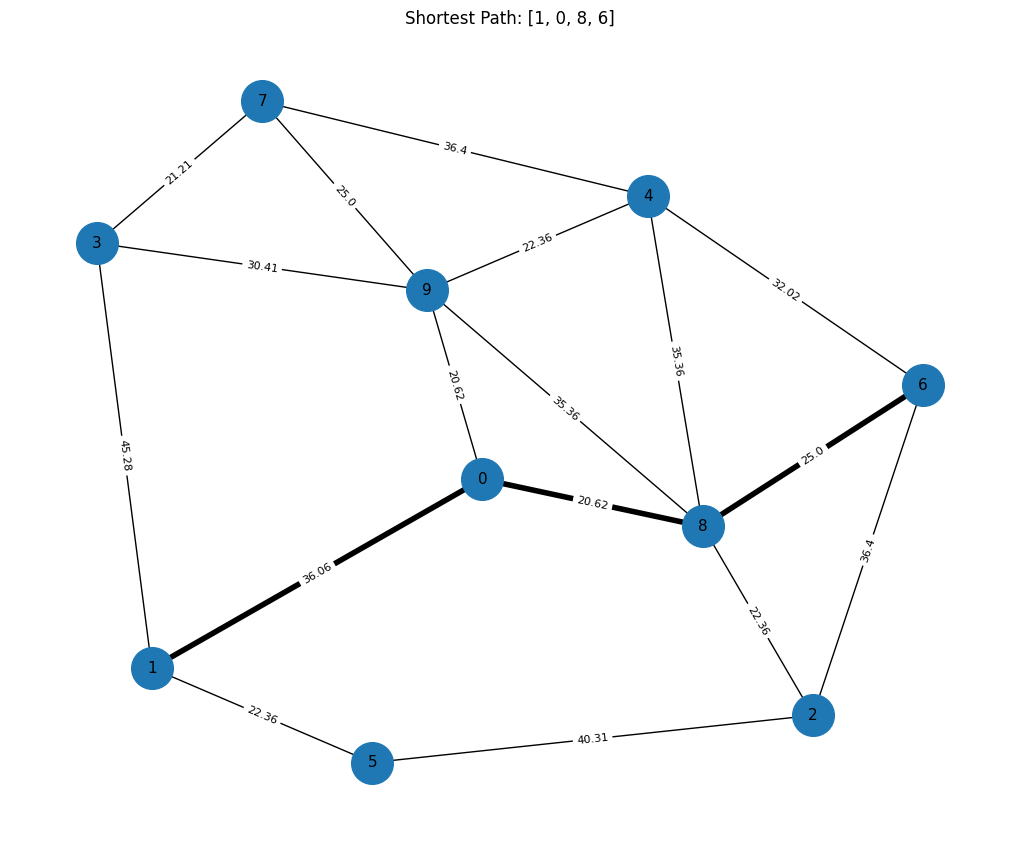

In [ ]:
# The thicker edges show the shortest path

result = find_shortest_path(
    graph,
    1,
    6
)

plot_shortest_path(
    transport_graph,
    locations,
    result["path"]
)

# **Compare Dijkstra with manual path selection**

In [ ]:
# Compare Dijkstra with manual path selection

manual_path_1 = [1, 5, 2, 6]
manual_path_2 = [1, 0, 8, 6]

print(
    "Manual path 1:",
    manual_path_1
)

print(
    "Cost:",
    calculate_path_cost(
        manual_path_1,
        graph
    )
)

print()

print(
    "Manual path 2:",
    manual_path_2
)

print(
    "Cost:",
    calculate_path_cost(
        manual_path_2,
        graph
    )
)

print()

print(
    "Dijkstra path:",
    result["path"]
)

print(
    "Dijkstra cost:",
    result["cost"]
)

Manual path 1: [1, 5, 2, 6]
Cost: 99.07

Manual path 2: [1, 0, 8, 6]
Cost: 81.68

Dijkstra path: [1, 0, 8, 6]
Dijkstra cost: 81.68


In [ ]:
# Verify with NetworkX

networkx_path = nx.dijkstra_path(
    transport_graph,
    source=1,
    target=6,
    weight="weight"
)

networkx_cost = nx.dijkstra_path_length(
    transport_graph,
    source=1,
    target=6,
    weight="weight"
)

print(
    "NetworkX path:",
    networkx_path
)

print(
    "NetworkX cost:",
    round(networkx_cost, 2)
)

NetworkX path: [1, 0, 8, 6]
NetworkX cost: 81.68


# **Save reusable Dijkstra functions**

Mount Google Drive and create the folder

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# create a folder in Drive called modules inside PhD Optimisation Code

import os

module_folder = (
    "/content/drive/MyDrive/"
    "PhD_Optimisation_Code/modules"
)

os.makedirs(
    module_folder,
    exist_ok=True
)

print("Module folder created:", module_folder)

Module folder created: /content/drive/MyDrive/PhD_Optimisation_Code/modules


### Save the reusable code

In [ ]:
%%writefile /content/drive/MyDrive/PhD_Optimisation_Code/modules/shortest_path_algorithms.py

import math
import heapq


def dijkstra(graph_data, start_node, destination_node):
    if start_node not in graph_data:
        raise ValueError(
            f"Start node {start_node} does not exist."
        )

    if destination_node not in graph_data:
        raise ValueError(
            f"Destination node {destination_node} does not exist."
        )

    distances = {
        node: math.inf
        for node in graph_data
    }

    predecessors = {
        node: None
        for node in graph_data
    }

    distances[start_node] = 0

    unvisited_queue = [
        (0, start_node)
    ]

    visited_nodes = set()

    while unvisited_queue:
        current_distance, current_node = heapq.heappop(
            unvisited_queue
        )

        if current_node in visited_nodes:
            continue

        visited_nodes.add(current_node)

        if current_node == destination_node:
            break

        for neighbour, edge_weight in graph_data[
            current_node
        ].items():

            new_distance = (
                current_distance
                + edge_weight
            )

            if new_distance < distances[neighbour]:
                distances[neighbour] = new_distance
                predecessors[neighbour] = current_node

                heapq.heappush(
                    unvisited_queue,
                    (
                        new_distance,
                        neighbour
                    )
                )

    return (
        distances,
        predecessors,
        visited_nodes
    )


def reconstruct_path(
    predecessors,
    start_node,
    destination_node
):
    path = []
    current_node = destination_node

    while current_node is not None:
        path.append(current_node)

        if current_node == start_node:
            break

        current_node = predecessors[current_node]

    path.reverse()

    if not path or path[0] != start_node:
        return None

    return path


def find_dijkstra_path(
    graph_data,
    start_node,
    destination_node
):
    distances, predecessors, visited_nodes = dijkstra(
        graph_data,
        start_node,
        destination_node
    )

    path = reconstruct_path(
        predecessors,
        start_node,
        destination_node
    )

    if path is None:
        return {
            "path": None,
            "cost": math.inf,
            "visited_nodes": visited_nodes
        }

    return {
        "path": path,
        "cost": round(
            distances[destination_node],
            2
        ),
        "visited_nodes": visited_nodes
    }

Writing /content/drive/MyDrive/PhD_Optimisation_Code/modules/shortest_path_algorithms.py


# **Test that the saved file works**

In [ ]:
import sys

module_folder = (
    "/content/drive/MyDrive/"
    "PhD_Optimisation_Code/modules"
)

if module_folder not in sys.path:
    sys.path.append(module_folder)

In [ ]:
# Then import the reusable function:

from shortest_path_algorithms import find_dijkstra_path

In [ ]:
# Testing using same graph created earlier

test_result = find_dijkstra_path(
    graph,
    1,
    6
)

print("Path:", test_result["path"])
print("Cost:", test_result["cost"])
print(
    "Visited nodes:",
    test_result["visited_nodes"]
)

Path: [1, 0, 8, 6]
Cost: 81.68
Visited nodes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


# **Important limitation**



## Limitation of Dijkstra's algorithm

Dijkstra's algorithm requires non-negative edge weights.

It should not be used when an edge has a negative cost.

In transport problems, distances and travel times are normally non-negative, so this condition is usually satisfied.

## What Dijkstra solves

Dijkstra's algorithm solves a shortest-path problem.

It finds the cheapest path between one starting location and one destination.

It does not decide the order for visiting all customers.

It does not allocate customers to vehicles.

It does not enforce vehicle capacity.

Therefore, it does not solve the full vehicle-routing problem.

## What I learned

- Dijkstra's algorithm finds the shortest path in a weighted graph with non-negative edge weights.
- Every node initially has a distance of infinity except the starting node, which has distance 0.
- The priority queue helps select the node with the smallest current distance.
- Relaxation checks whether a route through the current node gives a shorter distance to a neighbour.
- The predecessor dictionary records how each node was reached.
- The shortest path is reconstructed by following predecessors backwards from the destination.
- Dijkstra finds a shortest path between two nodes, not a full route visiting every customer.